# **Import Modules**

In [1]:
import numpy as np
import pandas as pd

# **Load The Dataset**

In [2]:
df = pd.read_csv('Tweets.csv')

In [3]:
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [4]:
df.sample(5)

,textID,text,selected_text,sentiment
13655,8283f525c5,ah . thanks .. appreciate it,ah . thanks .. appreciate it,positive
2004,31098bb260,wishes he had realized his wife hadn`t held on...,his wife hadn`t held onto the debit card be,negative
24744,629b112918,anticipating a tough day ahead,anticipating a tough day ahead,negative
10829,5d905b2eaf,i`m a huge fan of Take That since i was a bab...,a huge fan,positive
10878,346755a77b,?Happy Birthday to u? Happy Birthday to u? Ha...,?Happy,positive


In [5]:
df.shape

(27481, 4)

In [6]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

# **Data Cleaning**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [8]:
df.isnull().sum()

,0
textID,0
text,1
selected_text,1
sentiment,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df[['text', 'sentiment']].dropna().drop_duplicates().reset_index(drop=True)


In [11]:
df.head()

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [12]:
df['sentiment'].value_counts()

,count
sentiment,
neutral,11117
positive,8582
negative,7781


In [13]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [14]:
df['sentiment'] = encoder.fit_transform(df['sentiment'])

In [15]:
df['sentiment'].value_counts()

,count
sentiment,
1,11117
2,8582
0,7781


- neutral comment = 1, positive comment = 2, negative comment = 0

In [16]:
df.head()

,text,sentiment
0,"I`d have responded, if I were going",1
1,Sooo SAD I will miss you here in San Diego!!!,0
2,my boss is bullying me...,0
3,what interview! leave me alone,0
4,"Sons of ****, why couldn`t they put them on t...",0


In [17]:
df.shape

(27480, 2)

# **EDA**

In [18]:
df['sentiment'].value_counts()

,count
sentiment,
1,11117
2,8582
0,7781


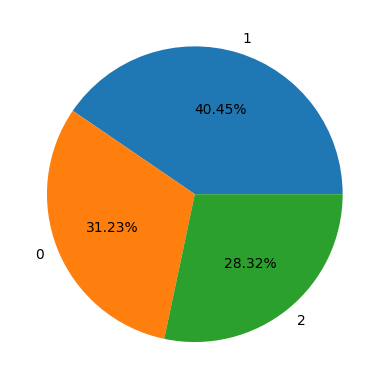

In [19]:
import matplotlib.pyplot as plt

plt.pie(df['sentiment'].value_counts(), labels=df['sentiment'].unique(), autopct='%0.2f%%')
plt.show()


# Download required NLTK data

In [20]:
import nltk

In [21]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [22]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [23]:
# num of cahracters
df['num_characters'] = df['text'].apply(len)

In [24]:
df.head()

,text,sentiment,num_characters
0,"I`d have responded, if I were going",1,36
1,Sooo SAD I will miss you here in San Diego!!!,0,46
2,my boss is bullying me...,0,25
3,what interview! leave me alone,0,31
4,"Sons of ****, why couldn`t they put them on t...",0,75


In [25]:
# num of words

df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [26]:
x = 'I love you '

In [27]:
nltk.word_tokenize(x)

['I', 'love', 'you']

In [28]:
df.head()

,text,sentiment,num_characters,num_words
0,"I`d have responded, if I were going",1,36,10
1,Sooo SAD I will miss you here in San Diego!!!,0,46,13
2,my boss is bullying me...,0,25,6
3,what interview! leave me alone,0,31,6
4,"Sons of ****, why couldn`t they put them on t...",0,75,20


In [29]:
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [30]:
df.head()

,text,sentiment,num_characters,num_words,num_sentences
0,"I`d have responded, if I were going",1,36,10,1
1,Sooo SAD I will miss you here in San Diego!!!,0,46,13,2
2,my boss is bullying me...,0,25,6,1
3,what interview! leave me alone,0,31,6,2
4,"Sons of ****, why couldn`t they put them on t...",0,75,20,1


In [31]:
df.columns

Index(['text', 'sentiment', 'num_characters', 'num_words', 'num_sentences'], dtype='object')

In [32]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,27480.000000,27480.000000,27480.000000
mean,68.330022,15.953748,1.713173
std,35.603870,8.558654,0.965417
min,3.000000,1.000000,1.000000
25%,39.000000,9.000000,1.000000
50%,64.000000,15.000000,1.000000
75%,97.000000,22.000000,2.000000
max,141.000000,106.000000,34.000000


In [33]:
# neutral comments

df[df['sentiment'] == 1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,11117.00000,11117.000000,11117.000000
mean,65.20680,15.148062,1.623370
std,36.40755,8.702079,0.971622
min,3.00000,1.000000,1.000000
25%,35.00000,8.000000,1.000000
50%,59.00000,14.000000,1.000000
75%,94.00000,22.000000,2.000000
max,141.00000,106.000000,34.000000


In [34]:
# positive comments

df[df['sentiment'] == 2][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,8582.000000,8582.000000,8582.000000
mean,70.419133,16.269518,1.835470
std,34.647770,8.299568,0.988907
min,5.000000,1.000000,1.000000
25%,42.000000,9.000000,1.000000
50%,67.000000,15.000000,2.000000
75%,98.000000,23.000000,2.000000
max,138.000000,55.000000,19.000000


In [35]:
# negative comments

df[df['sentiment'] == 0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,7781.000000,7781.000000,7781.000000
mean,70.488112,16.756587,1.706593
std,35.155991,8.536245,0.914546
min,5.000000,1.000000,1.000000
25%,42.000000,10.000000,1.000000
50%,66.000000,16.000000,1.000000
75%,98.000000,23.000000,2.000000
max,141.000000,63.000000,10.000000


<Axes: xlabel='num_characters', ylabel='Count'>

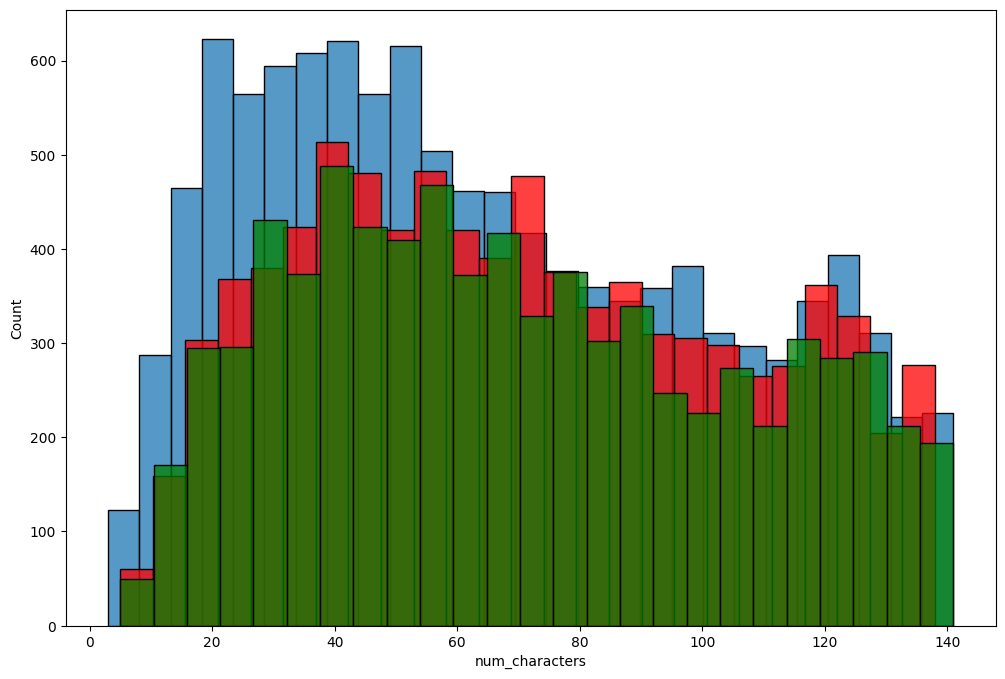

In [36]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.histplot(df[df['sentiment'] == 1]['num_characters'])
sns.histplot(df[df['sentiment'] == 2]['num_characters'], color='red')
sns.histplot(df[df['sentiment'] == 0]['num_characters'], color='green')

<Axes: xlabel='num_words', ylabel='Count'>

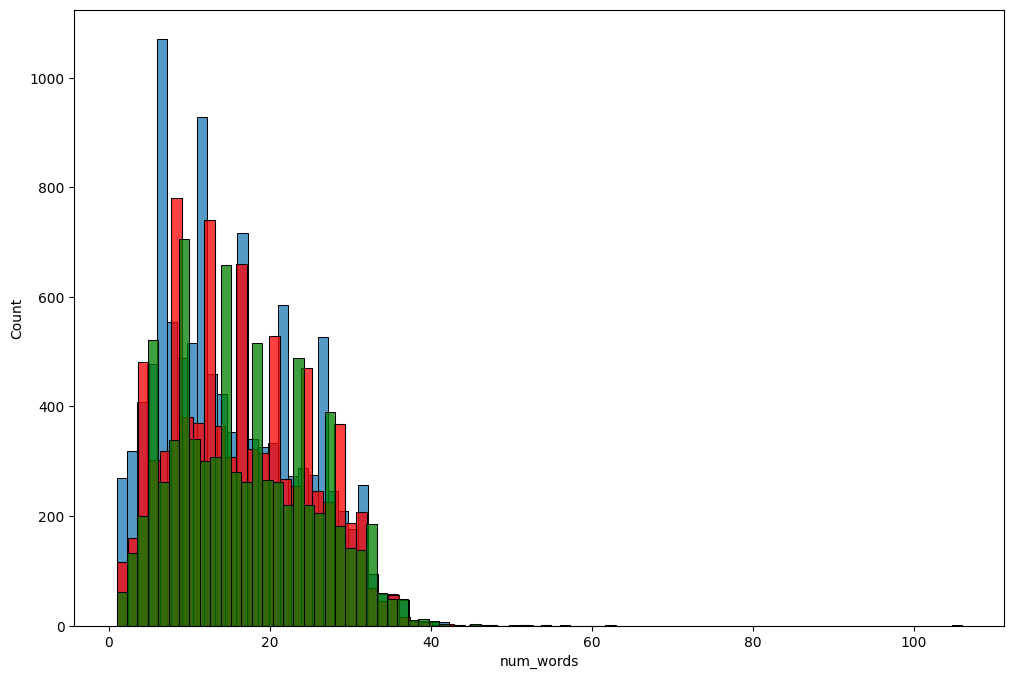

In [37]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['sentiment'] == 1]['num_words'])
sns.histplot(df[df['sentiment'] == 2]['num_words'], color='red')
sns.histplot(df[df['sentiment'] == 0]['num_words'], color='green')

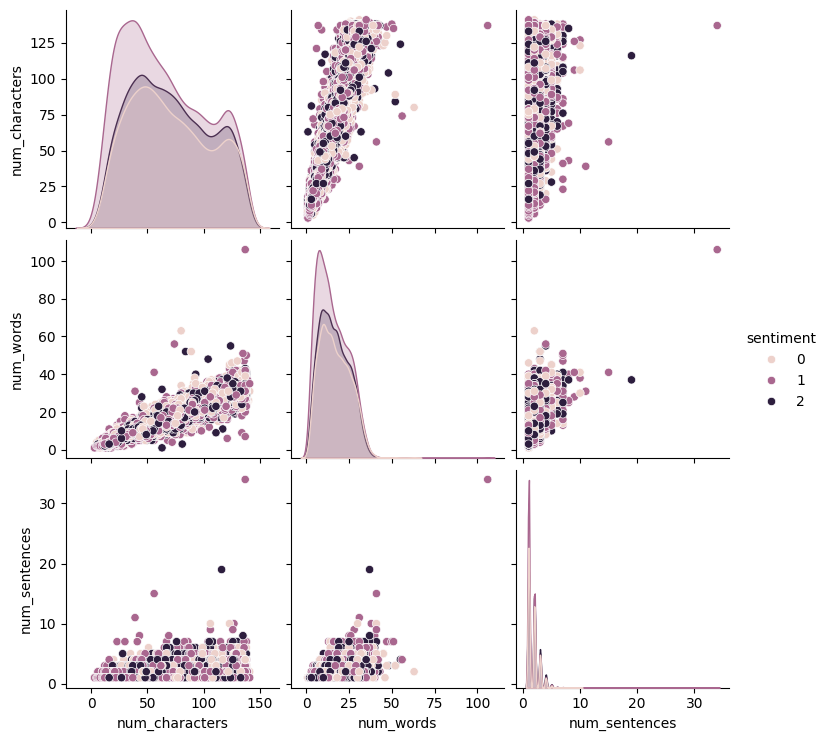

In [38]:
sns.pairplot(df, hue='sentiment')

<Axes: >

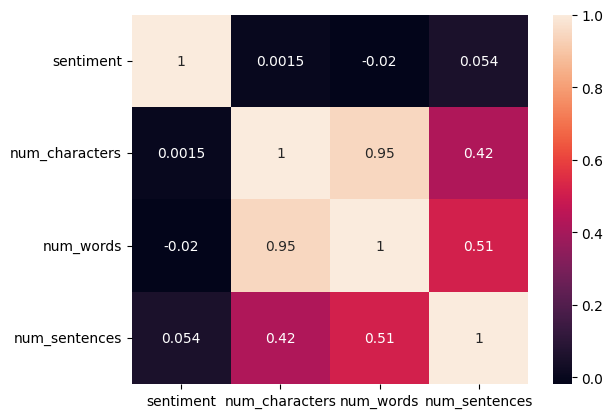

In [39]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

# **Data Preprocessing**

- Lower case
- Tokenization
- Removing Special Characters
- Removing Stop Words and Punctuations
- Stemming

In [40]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()


In [41]:
import string
from nltk.corpus import stopwords
import re

In [42]:
def tranform_text(text):

  # Lower Case

  text = text.lower()

  # Remove URLs
  text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)

  # Remove mentions (@user) and hashtags (#tag)
  text = re.sub(r"@\w+|#", '', text)

  # Tokenization

  text = nltk.word_tokenize(text)

  # Remove punctuation + stopwords

  cleaned_tokens = []

  for word in text:
    if word.isalnum() and word not in string.punctuation and word not in stopwords.words('english'):
      cleaned_tokens.append(word)

  # Apply stemming
  stemmed_tokens = []

  for word in cleaned_tokens:
    stemmed_tokens.append(ps.stem(word))

  # Join back to string

  return ' '.join(stemmed_tokens)

In [43]:
df['transformed_text'] = df['text'].apply(tranform_text)

In [44]:
df.head()

,text,sentiment,num_characters,num_words,num_sentences,transformed_text
0,"I`d have responded, if I were going",1,36,10,1,respond go
1,Sooo SAD I will miss you here in San Diego!!!,0,46,13,2,sooo sad miss san diego
2,my boss is bullying me...,0,25,6,1,boss bulli
3,what interview! leave me alone,0,31,6,2,interview leav alon
4,"Sons of ****, why couldn`t they put them on t...",0,75,20,1,son put releas alreadi bought


# Word Cloud

In [45]:
from wordcloud import WordCloud

In [46]:
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [47]:
neutral_wc = wc.generate(df[df['sentiment'] == 1]['transformed_text'].str.cat(sep=' '))

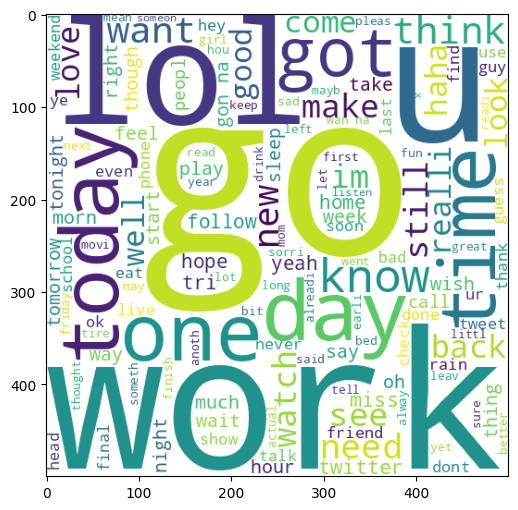

In [48]:
plt.figure(figsize=(15,6))
plt.imshow(neutral_wc)

In [49]:
positive_wc = wc.generate(df[df['sentiment'] == 2]['transformed_text'].str.cat(sep=' '))

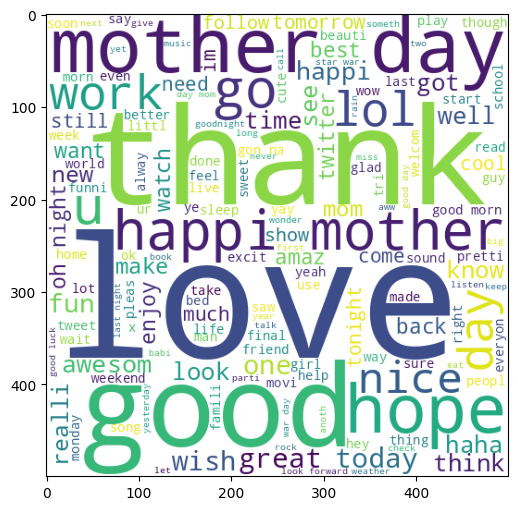

In [50]:
plt.figure(figsize=(15,6))
plt.imshow(positive_wc)

In [51]:
negative_wc = wc.generate(df[df['sentiment'] == 0]['transformed_text'].str.cat(sep=' '))

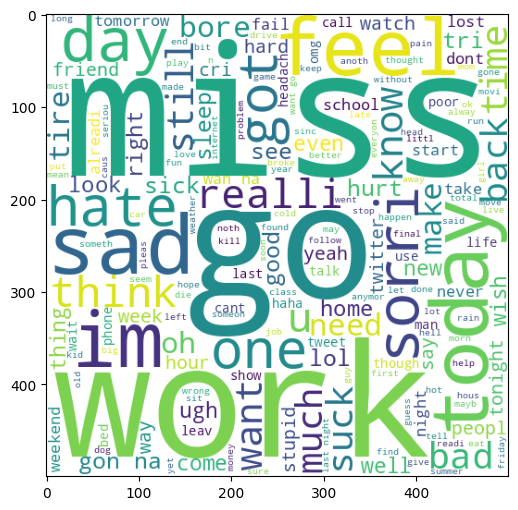

In [52]:
plt.figure(figsize=(15,6))
plt.imshow(negative_wc)

In [53]:
# neutral
neutral_corpus=[]
for msg in df[df['sentiment'] == 1]['transformed_text'].tolist():
  for word in msg.split():
    neutral_corpus.append(word)


In [54]:
len(neutral_corpus)

72644

In [55]:
from collections import Counter

In [56]:
neutral_counts = Counter(neutral_corpus).most_common(30)

In [57]:
df_neutral = pd.DataFrame(neutral_counts, columns=['word', 'count'])

In [58]:
df_neutral.head(1)

,word,count
0,go,1059


/tmp/ipython-input-476623196.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_neutral['word'], y=df_neutral['count'], palette='Set2')


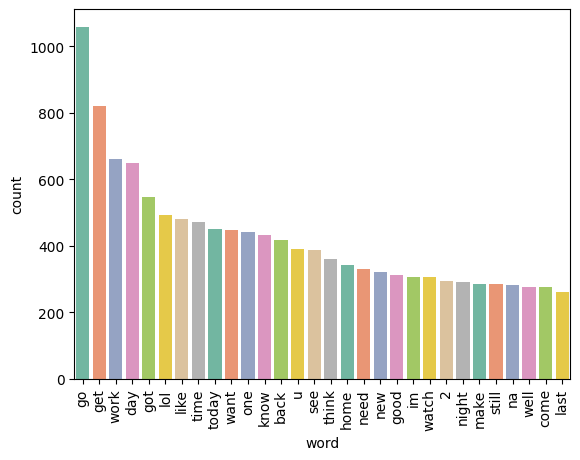

In [59]:
sns.barplot(x=df_neutral['word'], y=df_neutral['count'], palette='Set2')
plt.xticks(rotation='vertical')
plt.show()

In [60]:
# positive
positive_corpus = []
for msg in df[df['sentiment'] == 2]['transformed_text'].tolist():
  for word in msg.split():
    positive_corpus.append(word)


In [61]:
positive_counts = Counter(positive_corpus).most_common(30)

In [62]:
df_positive = pd.DataFrame(positive_counts, columns=['word', 'count'])

/tmp/ipython-input-3557369228.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_positive['word'], y=df_positive['count'], palette='Set2')


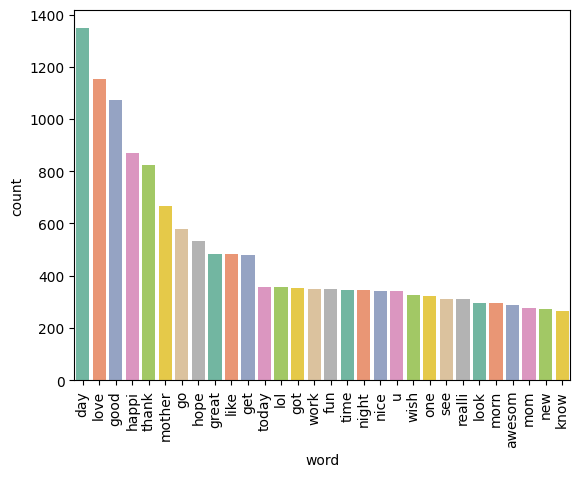

In [63]:
sns.barplot(x=df_positive['word'], y=df_positive['count'], palette='Set2')
plt.xticks(rotation='vertical')
plt.show()

In [64]:
# negative

negative_corpus = []
for msg in df[df['sentiment'] == 0]['transformed_text'].tolist():
  for word in msg.split():
    negative_corpus.append(word)

In [65]:
negative_counts = Counter(negative_corpus).most_common(30)

In [66]:
df_negative = pd.DataFrame(negative_counts, columns=['word', 'count'])

/tmp/ipython-input-2279853796.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_negative['word'], y=df_negative['count'], palette='Set2')


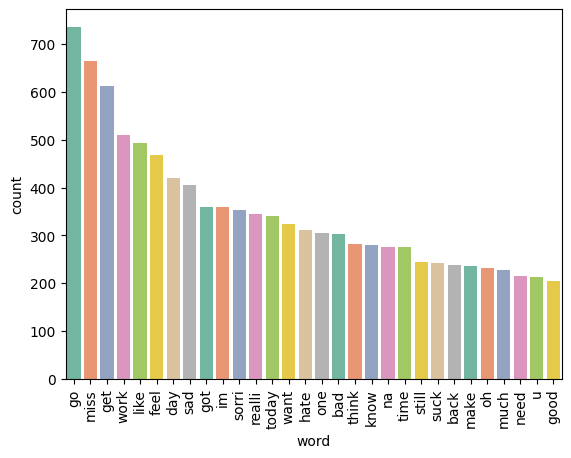

In [67]:
sns.barplot(x=df_negative['word'], y=df_negative['count'], palette='Set2')
plt.xticks(rotation='vertical')
plt.show()

In [68]:
# Text Vectorization
# using Bag of Words
df.head()

,text,sentiment,num_characters,num_words,num_sentences,transformed_text
0,"I`d have responded, if I were going",1,36,10,1,respond go
1,Sooo SAD I will miss you here in San Diego!!!,0,46,13,2,sooo sad miss san diego
2,my boss is bullying me...,0,25,6,1,boss bulli
3,what interview! leave me alone,0,31,6,2,interview leav alon
4,"Sons of ****, why couldn`t they put them on t...",0,75,20,1,son put releas alreadi bought


# **Model Building**

In [69]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [70]:
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [71]:
#X = cv.fit_transform(df['transformed_text']).toarray()
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [72]:
X.shape

(27480, 3000)

In [73]:
y = df['sentiment'].values

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [76]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

In [77]:
gnb = GaussianNB()
mnb= MultinomialNB()
bnb = BernoulliNB()

In [78]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(classification_report(y_test, y_pred1))
#print(precision_score(y_test, y_pred1))

0.4566957787481805
[[ 958  131  476]
 [ 713  218 1256]
 [ 293  117 1334]]
              precision    recall  f1-score   support

           0       0.49      0.61      0.54      1565
           1       0.47      0.10      0.16      2187
           2       0.44      0.76      0.55      1744

    accuracy                           0.46      5496
   macro avg       0.46      0.49      0.42      5496
weighted avg       0.46      0.46      0.40      5496



In [79]:
# MultinomialNB

mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)

print("MultinomialNB Results")
print("Accuracy:", accuracy_score(y_test, y_pred_mnb))
print(confusion_matrix(y_test, y_pred_mnb))
print(classification_report(y_test, y_pred_mnb))

MultinomialNB Results
Accuracy: 0.645924308588064
[[ 774  709   82]
 [ 232 1731  224]
 [  56  643 1045]]
              precision    recall  f1-score   support

           0       0.73      0.49      0.59      1565
           1       0.56      0.79      0.66      2187
           2       0.77      0.60      0.68      1744

    accuracy                           0.65      5496
   macro avg       0.69      0.63      0.64      5496
weighted avg       0.68      0.65      0.64      5496



In [80]:
# BernoulliNB
bnb = BernoulliNB()
bnb.fit(X_train, y_train)
y_pred_bnb = bnb.predict(X_test)

print("BernoulliNB Results")
print("Accuracy:", accuracy_score(y_test, y_pred_bnb))
print(confusion_matrix(y_test, y_pred_bnb))
print(classification_report(y_test, y_pred_bnb))

BernoulliNB Results
Accuracy: 0.6697598253275109
[[ 943  526   96]
 [ 326 1597  264]
 [  86  517 1141]]
              precision    recall  f1-score   support

           0       0.70      0.60      0.65      1565
           1       0.60      0.73      0.66      2187
           2       0.76      0.65      0.70      1744

    accuracy                           0.67      5496
   macro avg       0.69      0.66      0.67      5496
weighted avg       0.68      0.67      0.67      5496



In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier


# **Logistic Regression**

In [82]:
lr = LogisticRegression(max_iter=1000)

In [83]:
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.6910480349344978
[[ 937  528  100]
 [ 274 1671  242]
 [  64  490 1190]]
              precision    recall  f1-score   support

           0       0.73      0.60      0.66      1565
           1       0.62      0.76      0.69      2187
           2       0.78      0.68      0.73      1744

    accuracy                           0.69      5496
   macro avg       0.71      0.68      0.69      5496
weighted avg       0.70      0.69      0.69      5496



# **Random Forest**

In [84]:
rf = RandomForestClassifier(n_jobs=-1)


In [85]:
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print('Precision:', precision_score(y_test, y_pred_rf, average='weighted'))
#print(confusion_matrix(y_test, y_pred_rf))
#print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.710334788937409
Precision: 0.7129073265868658


# **Support Vector Machine**

In [86]:
#svc = SVC(probability=True)
#
#svc.fit(X_train, y_train)
#y_pred_svc = svc.predict(X_test)
#
#print("Support Vector Machine Results")
#print("Accuracy:", accuracy_score(y_test, y_pred_svc))

In [ ]:
# Create performance DataFrame
performance_df = pd.DataFrame({
    'Algorithm': algorithms,
    'Accuracy': accuracies,
    'Precision': precisions
}).sort_values('Precision', ascending=False)

In [93]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")  # multiclass safe
    report = classification_report(y_test, y_pred)

    return accuracy, precision, report

In [89]:
models = {
    #'SVC' : svc,
    #'KN' : knc,
    'NB': bnb,
    #'DT': dtc,
    'LR': lr,
    'RF': rf
    #'AdaBoost': abc,
    #'BgC': bc,
    #'ETC': etc,
    #'GBDT':gbdt,
    #'xgb':xgb
}



In [94]:
accuracy_scores = []
precision_scores = []
#algorithms = []

for name, clf in models.items():
    current_accuracy, current_precision, report = train_classifier(
        clf, X_train, y_train, X_test, y_test
    )

    print(f"\nModel: {name}")
    print("Accuracy:", current_accuracy)
    print("Precision:", current_precision)
    print("Classification Report:\n", report)

    #lgorithms.append(name)                  # store algorithm name
    accuracy_scores.append(current_accuracy) # store only number
    precision_scores.append(current_precision)


Model: NB
Accuracy: 0.6697598253275109
Precision: 0.680101123317886
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.60      0.65      1565
           1       0.60      0.73      0.66      2187
           2       0.76      0.65      0.70      1744

    accuracy                           0.67      5496
   macro avg       0.69      0.66      0.67      5496
weighted avg       0.68      0.67      0.67      5496


Model: LR
Accuracy: 0.6910480349344978
Precision: 0.7030280304654549
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.60      0.66      1565
           1       0.62      0.76      0.69      2187
           2       0.78      0.68      0.73      1744

    accuracy                           0.69      5496
   macro avg       0.71      0.68      0.69      5496
weighted avg       0.70      0.69      0.69      5496


Model: RF
Accuracy: 0.7072416302765647
Precision: 

In [95]:
performance_df = pd.DataFrame({'Algorithm':models.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [96]:
performance_df

,Algorithm,Accuracy,Precision
2,RF,0.707242,0.710225
1,LR,0.691048,0.703028
0,NB,0.669760,0.680101


# **Voting Method**

In [97]:
from sklearn.ensemble import VotingClassifier

In [99]:
estimators = [('NB', bnb), ('LR', lr), ('RF', rf)]

In [109]:
voting = VotingClassifier(estimators, voting='soft')

In [110]:
voting.fit(X_train, y_train)

VotingClassifier(estimators=[('NB', BernoulliNB()),
                             ('LR', LogisticRegression(max_iter=1000)),
                             ('RF', RandomForestClassifier(n_jobs=-1))],
                 voting='soft')

In [111]:
y_pred_vt = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred_vt))
print("Precision",precision_score(y_test,y_pred_vt,average='weighted'))

Accuracy 0.7063318777292577
Precision 0.711896786590167


# **Stacking**

In [112]:
# Applying stacking

#from sklearn.ensemble import StackingClassifier

In [113]:
#final_estimator=DecisionTreeClassifier()

In [114]:
#clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [ ]:
#clf.fit(X_train, y_train)
#y_pred = clf.predict(X_test)
#print("Accuracy",accuracy_score(y_test,y_pred))
#print("Precision",precision_score(y_test,y_pred))

In [116]:
import pickle

# Suppose Voting Classifier is best
final_model = voting   # or rf, lr, etc.

# Save both model and vectorizer
pickle.dump(final_model, open("sentiment_model.pkl", "wb"))
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))


- Try to use in selected_text column for better accuracy